# Ellipse Trajectory Comparison

In [7]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# Make the local checkout importable when this notebook is run from examples/ode/2026-Jung.
REPO_ROOT = Path.cwd().parents[2]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import specular

BASE_DIR = Path.cwd()
FIG_DIR = BASE_DIR / 'figures'
TBL_DIR = BASE_DIR / 'tables'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TBL_DIR.mkdir(parents=True, exist_ok=True)

matplotlib.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'Times New Roman'

COLORS = {
    'exact': 'black',
    'SE': 'red',
    'SE5': 'green',
    'CN': 'purple',
}

print('specular version:', specular.__version__)


specular version: 1.2.0


In [8]:
def ellipse_rhs(a, b, p=0.0, q=0.0):
    def F(t, u):
        return -(b * b * (t - p)) / (a * a * (u - q))
    return F

def exact_upper(t, a, b, p=0.0, q=0.0):
    z = 1.0 - ((t - p) / a) ** 2
    return q + b * np.sqrt(np.maximum(0.0, z))

def ellipse_residual(t_values, u_values, a, b, p=0.0, q=0.0):
    return ((t_values - p) / a) ** 2 + ((u_values - q) / b) ** 2 - 1.0

def max_solution_error(t_values, u_values, a, b, p=0.0, q=0.0):
    exact_values = np.array([exact_upper(t, a, b, p, q) for t in t_values])
    return float(np.max(np.abs(exact_values - u_values)))


In [9]:
def run_case(a, b, name, h, p=0.0, q=0.0, t_0=None, T=None):
    if t_0 is None:
        t_0 = p - 0.9 * a
    if T is None:
        T = p + 0.9 * a

    F = ellipse_rhs(a, b, p, q)
    u_0 = float(exact_upper(t_0, a, b, p, q))

    result_SE = specular.ode.ellipse_scheme(
        F=F, t_0=t_0, u_0=u_0, T=T, a=a, b=b, h=h, tol=1e-12, max_iter=200
    )
    result_SE5 = specular.Euler_scheme(
        of_Type=5, F=F, t_0=t_0, u_0=u_0, T=T, h=h, tol=1e-12, max_iter=200
    )
    result_CN = specular.ode.Crank_Nicolson_scheme(
        F=F, t_0=t_0, u_0=u_0, T=T, h=h, tol=1e-12, max_iter=200
    )

    t_SE, u_SE = result_SE.history()
    t_SE5, u_SE5 = result_SE5.history()
    t_CN, u_CN = result_CN.history()

    theta = np.linspace(0.0, 2.0 * np.pi, 1000)
    ellipse_t = p + a * np.sin(theta)
    ellipse_u = q + b * np.cos(theta)

    exact_t = np.linspace(t_0, T, 1000)
    exact_u = exact_upper(exact_t, a, b, p, q)

    rows = []
    for method, t_values, u_values in [
        ('SE', t_SE, u_SE),
        ('SE5', t_SE5, u_SE5),
        ('CN', t_CN, u_CN),
    ]:
        residual = ellipse_residual(t_values, u_values, a, b, p, q)
        rows.append({
            'method': method,
            'max_solution_error': max_solution_error(t_values, u_values, a, b, p, q),
            'max_ellipse_residual': float(np.max(np.abs(residual))),
        })

    csv_path = TBL_DIR / f'ellipse_traj_{name}_errors.csv'
    with open(csv_path, 'w', encoding='utf-8') as f:
        f.write('method,max_solution_error,max_ellipse_residual\n')
        for row in rows:
            f.write(f"{row['method']},{row['max_solution_error']:.16e},{row['max_ellipse_residual']:.16e}\n")

    return {
        'name': name,
        'a': a,
        'b': b,
        'p': p,
        'q': q,
        't_0': t_0,
        'T': T,
        'h': h,
        'ellipse_t': ellipse_t,
        'ellipse_u': ellipse_u,
        'exact_t': exact_t,
        'exact_u': exact_u,
        'SE': (t_SE, u_SE),
        'SE5': (t_SE5, u_SE5),
        'CN': (t_CN, u_CN),
        'rows': rows,
        'csv_path': csv_path,
    }


In [10]:
def plot_case(ax, case, show_ylabel=True):
    a = case['a']
    b = case['b']
    p = case['p']
    q = case['q']

    ax.plot(case['ellipse_t'], case['ellipse_u'], color='0.75', linewidth=0.9, linestyle='--')
    exact_line, = ax.plot(case['exact_t'], case['exact_u'], color=COLORS['exact'], linewidth=1.8, label='ES')

    t_SE, u_SE = case['SE']
    se_line, = ax.plot(t_SE, u_SE, color=COLORS['SE'], linewidth=1.2, marker='o', markersize=4.5, markerfacecolor='none', markeredgecolor=COLORS['SE'], label='SE')

    t_SE5, u_SE5 = case['SE5']
    se5_line, = ax.plot(t_SE5, u_SE5, color=COLORS['SE5'], linewidth=1.2, marker='v', markersize=4.7, markerfacecolor='none', markeredgecolor=COLORS['SE5'], label='SE5')

    t_CN, u_CN = case['CN']
    cn_line, = ax.plot(t_CN, u_CN, color=COLORS['CN'], linewidth=1.2, marker='x', markersize=4.7, markeredgecolor=COLORS['CN'], label='CN')

    radius = 1.3 * max(a, b)
    ax.set_xlim(p - radius, p + radius)
    ax.set_ylim(q - radius, q + radius)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel(r'$t$', fontsize=11)
    if show_ylabel:
        ax.set_ylabel(r'$u$', fontsize=11)
    ax.set_title(rf'$a={a:g},\ b={b:g},\ h={case["h"]:g}$', fontsize=11)
    ax.grid(True, linewidth=0.4, alpha=0.5)
    ax.tick_params(axis='both', labelsize=9)

    return [exact_line, se_line, se5_line, cn_line]

def plot_two_cases(cases, filename='ellipse_traj_comparison'):
    subplot_size = 2.0
    legend_width = 0.72
    gap = 0.36
    left_margin = 0.48
    right_margin = 0.05
    bottom_margin = 0.45
    top_margin = 0.32

    width = left_margin + len(cases) * subplot_size + (len(cases) - 1) * gap + legend_width + right_margin
    height = bottom_margin + subplot_size + top_margin
    fig = plt.figure(figsize=(width, height))

    axes = []
    for i, case in enumerate(cases):
        left = (left_margin + i * (subplot_size + gap)) / width
        bottom = bottom_margin / height
        ax = fig.add_axes([left, bottom, subplot_size / width, subplot_size / height])
        axes.append(ax)

    handles = None
    for i, (ax, case) in enumerate(zip(axes, cases)):
        case_handles = plot_case(ax, case, show_ylabel=(i == 0))
        if handles is None:
            handles = case_handles

    labels = [handle.get_label() for handle in handles]
    legend_x = (left_margin + len(cases) * subplot_size + (len(cases) - 1) * gap + 0.15) / width
    legend_x = (left_margin + len(cases) * subplot_size + (len(cases) - 1) * gap + 0.10) / width
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(legend_x, 0.5), fontsize=9, frameon=True)

    pdf_path = FIG_DIR / f'{filename}.pdf'
    png_path = FIG_DIR / f'{filename}.png'
    # fig.savefig(pdf_path, dpi=1000, bbox_inches='tight')
    fig.savefig(png_path, dpi=1000, bbox_inches='tight')
    plt.show()

    return pdf_path, png_path


Running Crank-Nicolson scheme: 100%|██████████| 9/9 [00:00<?, ?it/s]


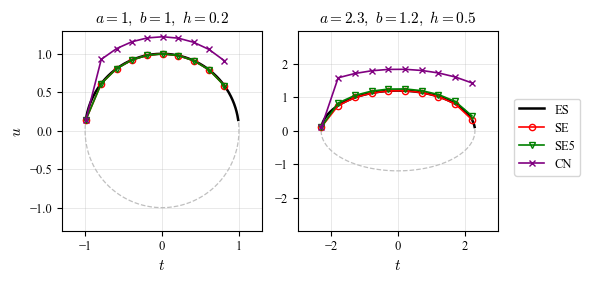

c:\Users\keeyobee\Research\specular-differentiation\examples\ode\2026-Jung\figures\ellipse_traj_comparison.pdf
c:\Users\keeyobee\Research\specular-differentiation\examples\ode\2026-Jung\figures\ellipse_traj_comparison.png


In [11]:
circle = run_case(a=1.0, b=1.0, name='circle', h=0.2, t_0=-0.99, T=0.99)
ellipse = run_case(a=2.3, b=1.2, name='ellipse', h=0.5, t_0=-2.29, T=2.29)

combined_pdf, combined_png = plot_two_cases([circle, ellipse])

print(combined_pdf)
print(combined_png)


In [12]:
for case in [circle, ellipse]:
    print(case['name'])
    for row in case['rows']:
        print(
            f"  {row['method']}: "
            f"solution error={row['max_solution_error']:.3e}, "
            f"ellipse residual={row['max_ellipse_residual']:.3e}"
        )


circle
  SE: solution error=2.579e-13, ellipse residual=3.735e-13
  SE5: solution error=2.579e-13, ellipse residual=3.735e-13
  CN: solution error=3.238e-01, ellipse residual=4.925e-01
ellipse
  SE: solution error=3.202e-13, ellipse residual=3.882e-13
  SE5: solution error=1.116e-01, ellipse residual=9.271e-02
  CN: solution error=1.097e+00, ellipse residual=1.350e+00
